# 🍷 TidyTuesday 2026 — US Agricultural Tariffs
## Wine Through the WTO Lens: How Much Does Europe Pay?

**Dataset:** US Agricultural Tariff Schedule (1989–2024)  
**Source:** [TidyTuesday 2026, Week 17](https://github.com/rfordatascience/tidytuesday)

---

### Context
The US applies tariffs to imported wine under the **MFN (Most Favored Nation)** rate —
the default WTO rate charged to any country without a bilateral Free Trade Agreement.
This includes the entire European Union: France, Spain, Italy, Portugal.

Countries *with* a US FTA (Chile, Australia, etc.) pay **$0.00/kg** — duty free.
Europe has no such deal, and none is on the horizon.

This notebook explores how MFN wine tariffs evolved from 1997 to 2024,
broken down by wine category relevant to European exports:

| Category | HTS Codes | Examples |
|---|---|---|
| 🥂 Sparkling | 22041000 | Champagne, Cava, Prosecco |
| 🍷 Still, light (≤14% alc.) | 22042130 & 22042150 | Vinho Verde, Rioja, Pinot Grigio |
| 🍷 Still, strong (>14% alc.) | 22042180 | Amarone, Priorat, big reds |
| 🍾 Bulk (>2L containers) | 22042220 & 22042240 & 22042260 & 22042280 & 22042920 & 22042940 & 22042960 & 22042961 & 22042980 | Commercial/restaurant supply |

---

### Files used
- `tariff_agricultural.csv` — tariff rates by HTS code, agreement, and date
- `tariff_codes.csv` — HTS code descriptions

In [19]:
import pandas as pd

# HTS8 codes for our four wine categories
WINE_HTS = {
    'sparkling':        [22041000],
    'light':            [22042130, 22042150],
    'strong':           [22042180],
    'bulk':             [22042220, 22042240, 22042260, 22042280, 22042920, 22042940, 22042960, 22042961, 22042980],
}

# Flatten to a single list for filtering
all_wine_codes = [code for codes in WINE_HTS.values() for code in codes]

# Load only the rows we need
df_raw = pd.read_csv('tariff_agricultural.csv')
df_wine = df_raw[df_raw['hts8'].isin(all_wine_codes)].copy()

# Add a human-readable category column
code_to_category = {code: cat for cat, codes in WINE_HTS.items() for code in codes}
df_wine['category'] = df_wine['hts8'].map(code_to_category)

# Quick sanity check
print(f"Total rows: {len(df_wine)}")
print(f"\nRows per category:")
print(df_wine['category'].value_counts())
print(f"\nAgreements present:")
print(df_wine['agreement'].value_counts())

Total rows: 2996

Rows per category:
category
bulk         1487
light         701
sparkling     404
strong        404
Name: count, dtype: int64

Agreements present:
agreement
mfn          271
mexico       260
col2         241
cbi          236
jordan       217
singapore    196
chile        196
australia    191
atpa         184
morocco      183
dr_cafta     148
bahrain      140
oman         130
peru         108
korea         99
panama        71
colombia      63
usmca         33
columbia      16
canada        13
Name: count, dtype: int64


In [20]:
# Define agreements to keep
MFN = 'mfn'

FTA_AGREEMENTS = [
    'australia', 'bahrain', 'canada', 'chile', 'dr_cafta',
    'dr_cafta_plus', 'israel_fta', 'japan', 'jordan', 'korea',
    'mexico', 'morocco', 'oman', 'singapore'
]

KEEP_AGREEMENTS = [MFN] + FTA_AGREEMENTS

# Filter for only MFN and FTA agreements
df_wine = df_wine[df_wine['agreement'].isin(KEEP_AGREEMENTS)].copy()

# Parse dates
df_wine['begin_effective_date'] = pd.to_datetime(df_wine['begin_effective_date'])
df_wine['end_effective_date']   = pd.to_datetime(df_wine['end_effective_date'], errors='coerce')

# Add a helper column: is this row MFN or FTA?
df_wine['agreement_type'] = df_wine['agreement'].apply(
    lambda x: 'MFN' if x == MFN else 'FTA'
)

# Sanity check
print(f"Total rows after filter: {len(df_wine)}")
print(f"\nRows per agreement_type:")
print(df_wine['agreement_type'].value_counts())
print(f"\nDate range:")
print(f"  earliest: {df_wine['begin_effective_date'].min().date()}")
print(f"  latest:   {df_wine['begin_effective_date'].max().date()}")

Total rows after filter: 2044

Rows per agreement_type:
agreement_type
FTA    1773
MFN     271
Name: count, dtype: int64

Date range:
  earliest: 1997-01-01
  latest:   2020-07-01


In [21]:
df_wine = df_wine.drop(columns=['ad_val_rate', 'rate_type_code'])

df_wine.head()

,hts8,begin_effective_date,end_effective_date,agreement,specific_rate,category,agreement_type
2117,22041000,1997-01-01,1997-12-31,mfn,0.254,sparkling,MFN
2119,22041000,1997-01-01,1997-12-31,mexico,0.000,sparkling,FTA
2122,22041000,1997-01-01,1997-12-31,canada,0.030,sparkling,FTA
2123,22042130,1997-01-01,1997-12-31,mfn,0.081,light,MFN
2125,22042130,1997-01-01,1997-12-31,mexico,0.059,light,FTA


In [22]:
# Extract year from begin date
df_wine['year'] = df_wine['begin_effective_date'].dt.year

# Aggregate: mean rate per year, category and agreement type
df_agg = (
    df_wine
    .groupby(['year', 'category', 'agreement_type'])['specific_rate']
    .mean()
    .reset_index()
)

# Sanity check
print(df_agg.shape)
print(df_agg.head(20))

(172, 4)
    year   category agreement_type  specific_rate
0   1997       bulk            FTA       0.068875
1   1997       bulk            MFN       0.183250
2   1997      light            FTA       0.034000
3   1997      light            MFN       0.081000
4   1997  sparkling            FTA       0.015000
5   1997  sparkling            MFN       0.254000
6   1997     strong            FTA       0.039000
7   1997     strong            MFN       0.217000
8   1998       bulk            FTA       0.098750
9   1998       bulk            MFN       0.177750
10  1998      light            FTA       0.049000
11  1998      light            MFN       0.075000
12  1998  sparkling            FTA       0.000000
13  1998  sparkling            MFN       0.235000
14  1998     strong            FTA       0.000000
15  1998     strong            MFN       0.201000
16  1999       bulk            FTA       0.078750
17  1999       bulk            MFN       0.173000
18  1999      light            FTA       

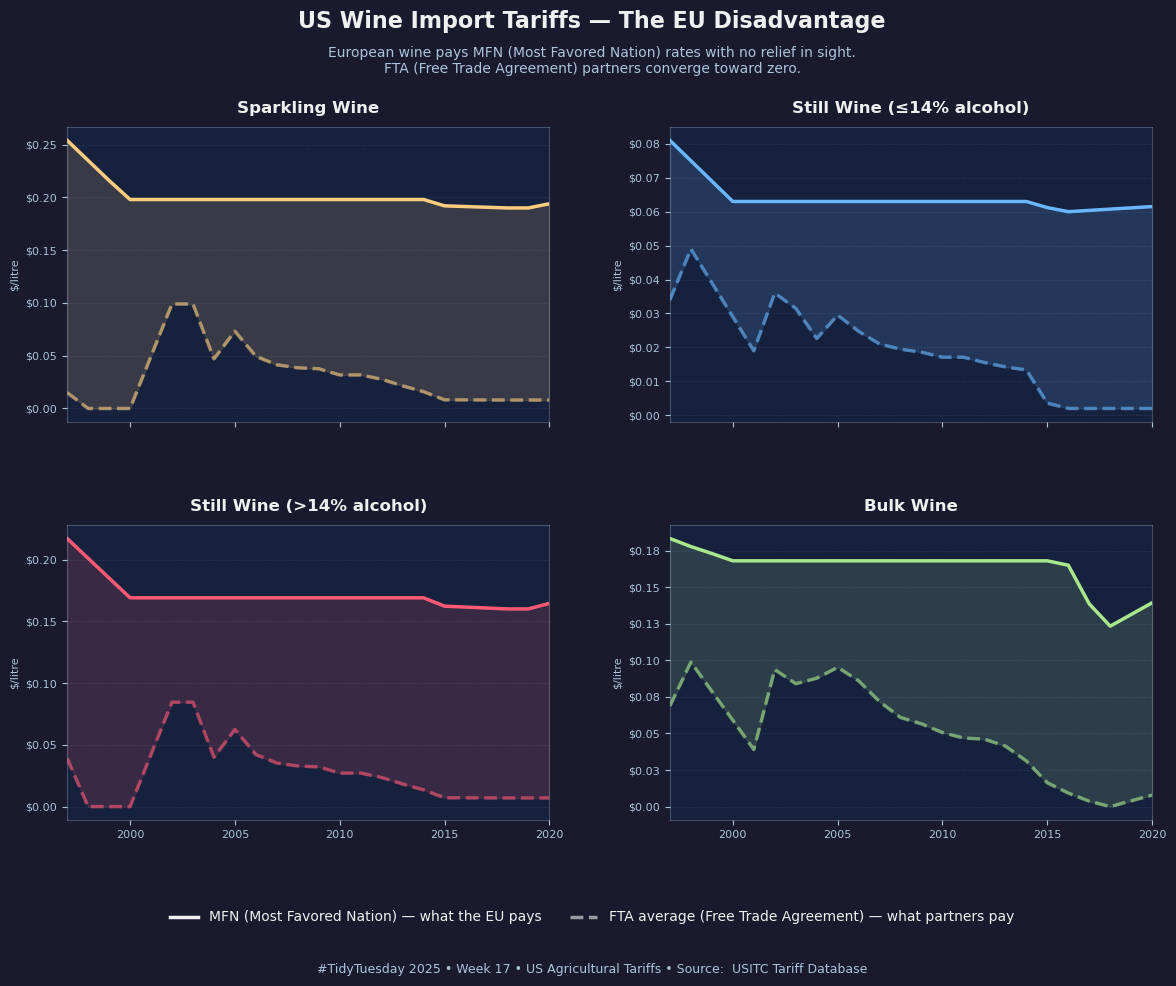

Saved to wine_tariffs.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ── Palette ───────────────────────────────────────────────────────────────────
DARK_BG   = '#1a1a2e'
PANEL_BG  = '#16213e'
GOLD      = "#fdcd7f"
ROSE      = "#fc5a73"
SAGE      = "#a9e78c"
SKY       = "#69b6fd"
MUTED     = "#acc4db"
WHITE     = '#f0f0f0'

CATEGORY_COLORS = {
    'sparkling': GOLD,
    'light':     SKY,
    'strong':    ROSE,
    'bulk':      SAGE,
}

CATEGORY_LABELS = {
    'sparkling': 'Sparkling Wine',
    'light':     'Still Wine (≤14% alcohol)',
    'strong':    'Still Wine (>14% alcohol)',
    'bulk':      'Bulk Wine',
}

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2, figsize=(14, 9),
    facecolor=DARK_BG,
    sharex=True
)
fig.subplots_adjust(hspace=0.35, wspace=0.25)

categories = ['sparkling', 'light', 'strong', 'bulk']

for ax, cat in zip(axes.flat, categories):
    ax.set_facecolor(PANEL_BG)
    color = CATEGORY_COLORS[cat]

    # Subset
    mfn = df_agg[(df_agg['category'] == cat) & (df_agg['agreement_type'] == 'MFN')]
    fta = df_agg[(df_agg['category'] == cat) & (df_agg['agreement_type'] == 'FTA')]

    # Sort by year
    mfn = mfn.sort_values('year')
    fta = fta.sort_values('year')

    # Fill the gap between the two lines
    all_years = sorted(set(mfn['year']) | set(fta['year']))
    mfn_interp = mfn.set_index('year')['specific_rate'].reindex(all_years).ffill()
    fta_interp = fta.set_index('year')['specific_rate'].reindex(all_years).ffill()
    ax.fill_between(all_years, mfn_interp, fta_interp,
                    alpha=0.15, color=color, label='_nolegend_')

    # Plot lines
    ax.plot(mfn['year'], mfn['specific_rate'],
            color=color, linewidth=2.5, label='MFN (EU rate)')
    ax.plot(fta['year'], fta['specific_rate'],
            color=color, linewidth=2.5, linestyle='--', alpha=0.6, label='FTA average')

    # Styling
    ax.set_title(CATEGORY_LABELS[cat], color=WHITE, fontsize=12,
                 fontweight='bold', pad=10)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2f'))
    ax.set_ylabel('$/litre', color=MUTED, fontsize=8)

    for spine in ax.spines.values():
        spine.set_edgecolor(MUTED)
        spine.set_alpha(0.3)

    ax.grid(axis='y', color=MUTED, alpha=0.15, linestyle=':')
    ax.set_xlim(1997, 2020)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=WHITE, linewidth=2.5,
           label='MFN (Most Favored Nation) — what the EU pays'),
    Line2D([0], [0], color=WHITE, linewidth=2.5, linestyle='--', alpha=0.6,
           label='FTA average (Free Trade Agreement) — what partners pay'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           frameon=False, fontsize=10, labelcolor=WHITE,
           bbox_to_anchor=(0.5, -0.02))

# ── Titles ────────────────────────────────────────────────────────────────────
fig.suptitle('US Wine Import Tariffs — The EU Disadvantage',
             color=WHITE, fontsize=16, fontweight='bold', y=1.01)
fig.text(0.5, 0.97,
         'European wine pays MFN (Most Favored Nation) rates with no relief in sight.\nFTA (Free Trade Agreement) partners converge toward zero.',
         color=MUTED, fontsize=10, ha='center', va='top')

# ── Footer ────────────────────────────────────────────────────────────────────
fig.text(0.5, -0.06,
         '#TidyTuesday 2025 • Week 17 • US Agricultural Tariffs • Source:  USITC Tariff Database',
         color=MUTED, fontsize=9, ha='center')

plt.savefig('wine_tariffs.png', dpi=180, bbox_inches='tight',
            facecolor=DARK_BG)
plt.show()
print("Saved to wine_tariffs.png")